In [2]:
from fastai.vision.all import *

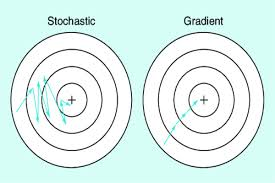

In [3]:
time = torch.arange(0,20).float()
time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.])

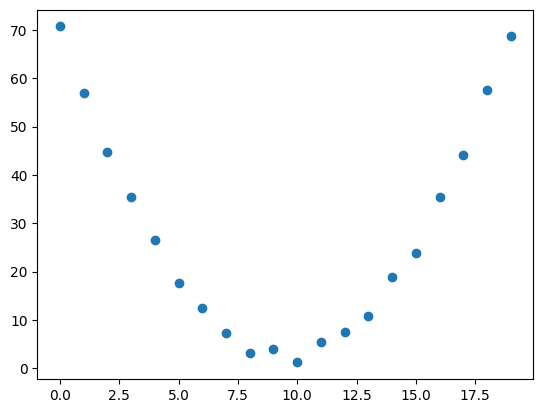

In [6]:
speed = torch.rand(20)*3+0.75*(time-9.5)**2+1

# plotting
import matplotlib.pyplot as plt
plt.scatter(time,speed)
plt.show()

**y = ax^2 + bx +c**

**speed = a time^2 + b time + c**

a, b, c larni topish kerak

In [7]:
def f(t, params):
  a,b,c = params
  return a*t**2 + b*t + c

In [21]:
def mse(preds, targets):
  return ((preds-targets)**2).mean()

In [83]:
params = torch.rand(3).requires_grad_()

In [84]:
preds = f(time, params)

In [85]:
loss = mse(preds, speed)
loss

tensor(6310.0811, grad_fn=<MeanBackward0>)

In [86]:
loss.backward()
params.grad

tensor([25198.4668,  1625.3759,    93.4635])

In [87]:
lr = 1e-5
params.data  -= lr * params.grad.data
params.grad = None

In [88]:
preds = f(time, params)
loss = mse(preds, speed)
loss

tensor(1735.1842, grad_fn=<MeanBackward0>)

In [114]:
def apply_step(params, prn=True):
  preds = f(time, params)
  loss = mse(preds, speed)
  loss.backward()
  params.data -= lr * params.grad.data
  params.grad = None
  if prn:
    print(loss.item())

In [118]:
for epoch in range(10):
  apply_step(params)

558.3768310546875
558.3740234375
558.3711547851562
558.3682861328125
558.3653564453125
558.3624267578125
558.3596801757812
558.356689453125
558.353759765625
558.3508911132812
